In [1]:
import cupy as cp
import numpy as np
import os
import sys
from core import *
import time
from joint_posterior import JointPosterior, JointZoomConfig
# from joint_likelihood import *
from joint_estimator import JointEstimator
from joint_kl import choose_next_bias

In [ ]:
DATA_DIR = r"C:\Users\Dinesh\UGP\bayesian_nmor\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_10"
#By scan 
scan_index = 0
bz_prior_range = 2
sigma_noise  = 0.4
#start time, curr_time
curr_time = 0.0
DATASET3 = DataContext(
                        sim_time = os.path.join(DATA_DIR, "t_array.csv"),
                        sim_freq = os.path.join(DATA_DIR, "delz_MHz.csv"),
                        sim_by = os.path.join(DATA_DIR, "dely_MHz.csv"),
                        sim_intensities = sorted([
                            os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0_dely_") and f.endswith(".csv")
                        ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0])),
                        exp_time = r"C:\Users\Dinesh\UGP\bayesian_nmor\DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\t_array_ Copy.csv",
                        exp_freq_axis = r"C:\Users\Dinesh\UGP\bayesian_nmor\DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_Y_MHz.csv",
                        exp_data = f"C:\\Users\\Dinesh\\UGP\\bayesian_nmor\\DataFiles_to_Dinesh_Pranav\\Data_files\\Experiment\\26_03_2026_CW_data\\Bz_V_Readout_By_{scan_index}.csv",
                        interpolator=r"C:\Users\Dinesh\UGP\bayesian_nmor\DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_10\gpu_sim_interpolator_new_normalisation_linear_spline_0.3_threshold.npz",
                        Sim_Aligned = True, 
                        Exp_Aligned = False,
                        sim_pulse_thresh=0.3, 
                        exp_pulse_thresh=0.3
                        )
DEFAULT_ESTIMATION_PARAMETERS = ParameterContext(
                            # num_iter=10,
                            curr_time = curr_time,
                            max_time = 70.0,
                            # tol_bz=1e-20,
                            # tol_by=1e-20,
                            t_step = 0.2,   
                            # fixed_by_estimate=0.0,
                            # fixed_bz_estimate=0.0,
                            B_unk_bound_transverse_upper=0.5,
                            B_unk_bound_longitudinal = bz_prior_range,
                            # print_plot = False,
                            # likelihood_mode_longitudinal="Gaussian",
                            # likelihood_mode_transverse="Gaussian",
                            sigma_noise_likelihood = sigma_noise,
                            )

In [40]:
t_sim, f_sim, by_sim, full_interp = get_final_interpolator(DATASET3, DEFAULT_ESTIMATION_PARAMETERS)
t_exp, f_bias_axis, exp_matrix = load_experiment(DATASET3, DATASET3.Exp_Aligned)
t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)


# bz_support = cp.arange(-DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_longitudinal, DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_longitudinal, DEFAULT_ESTIMATION_PARAMETERS.init_resolution_longitudinal)  # type: ignore
# curr_res_z = DEFAULT_ESTIMATION_PARAMETERS.init_resolution_longitudinal
# by_support = cp.arange(DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_transverse_lower, DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_transverse_upper, DEFAULT_ESTIMATION_PARAMETERS.init_resolution_transverse)  # type: ignore
# curr_res_y = DEFAULT_ESTIMATION_PARAMETERS.init_resolution_transverse
bz_support = cp.linspace(-DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_longitudinal, DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_longitudinal, 100)  # setting to 100 for simplicity

by_support = cp.linspace(DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_transverse_lower, DEFAULT_ESTIMATION_PARAMETERS.B_unk_bound_transverse_upper, 100)  # setting to 100 for simplicity


curr_bias = 0.0
start_time = DEFAULT_ESTIMATION_PARAMETERS.curr_time

#TODO Once you are done with streamlining these classes, move them into the run_experiment function as well. 

...Building Final Interpolator...
Time taken to load Interpolator: 3.0520451068878174
Loading Experiment from C:\Users\Dinesh\UGP\bayesian_nmor\DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_V_Readout_By_0.csv...
  > Exp Start: -0.1100s
0.19247961044311523 was the time taken to load exp data.


In [41]:
def run_experiment(save_path = None):

    ZOOM_CONFIG = JointZoomConfig(
    credible_mass=0.999,
    trigger_span_ratio=0.25,
    margin_cells=3,
    growth_factor=1.5,
    max_grid_points_per_axis=None,  # Set an explicit cap to permit grid growth.
    )

    posterior = JointPosterior(
        bz_support,
        by_support,
    )

    estimator = JointEstimator(
        posterior,
        full_interp,
        DEFAULT_ESTIMATION_PARAMETERS,
        zoom_config=ZOOM_CONFIG,
    )

    
    history = {
        "time": [],
        "map_bz": [],
        "map_by": [],
        "std_bz": [],
        "std_by": [],
        "bias": [],
        "expectedkl": [],
        "posteriors": [],
        "grid_shapes": [],
        "bz_axes": [],
        "by_axes": [],
        "zoom_events": [],
        "covariance_matrix": [],
    }

    time_cursor = DEFAULT_ESTIMATION_PARAMETERS.curr_time
    curr_bias = 0.0

    start_wall = time.time()
    loop_index = 0

    while time_cursor < DEFAULT_ESTIMATION_PARAMETERS.max_time:

        # ---------------------------------------------------------
        # Current control interval
        # ---------------------------------------------------------

        t_next = time_cursor + DEFAULT_ESTIMATION_PARAMETERS.t_step

        idx_start = cp.searchsorted(
            t_exp,
            cp.asarray(time_cursor),
        )

        idx_end = cp.searchsorted(
            t_exp,
            cp.asarray(t_next),
        )

        if idx_start >= idx_end:
            break

        # ---------------------------------------------------------
        # Snap bias to nearest available experiment column
        # ---------------------------------------------------------

        bias_idx = cp.abs(
            f_bias_axis - curr_bias
        ).argmin()

        curr_bias = f_bias_axis[bias_idx]

        LC_bias = f_bias_axis[1] - f_bias_axis[0]

        # ---------------------------------------------------------
        # Experimental measurement
        # ---------------------------------------------------------

        y_obs = exp_matrix[
            idx_start:idx_end,
            bias_idx,
        ]

        t_chunk = t_exp[
            idx_start:idx_end
        ]

        # ---------------------------------------------------------
        # Bayesian update
        # ---------------------------------------------------------

        summary = estimator.update(
            measurement=y_obs,
            times=t_chunk,
            applied_bias= [curr_bias, LC_bias],
        )  #Need to go into this function to characterise time usage

        # ---------------------------------------------------------
        # Save history
        # ---------------------------------------------------------

        history["time"].append(float(t_next))

        history["map_bz"].append(
            float(summary.map_bz)
        )

        history["map_by"].append(
            float(summary.map_by)
        )

        history["std_bz"].append(
            float(summary.std_bz)
        )

        history["std_by"].append(
            float(summary.std_by)
        )

        history["covariance_matrix"].append(
            summary.covariance.get()
        )

        history["bias"].append(
            float(curr_bias)
        )

        history["posteriors"].append(
            estimator.posterior.weights.get()
        )

        support_state = estimator.support_history[-1]
        history["grid_shapes"].append(support_state["grid_shape"])
        history["bz_axes"].append(support_state["bz_axis"])
        history["by_axes"].append(support_state["by_axis"])
        
        if (
            estimator.zoom_events
            and estimator.zoom_events[-1]["update_index"] == len(estimator.update_records)
        ):
            history["zoom_events"].append(estimator.zoom_events[-1])

        # ---------------------------------------------------------
        # Candidate bias range
        # ---------------------------------------------------------

        f_index_1 = cp.where(
            f_bias_axis > f_sim[10]
        )[0][0]

        f_index_2 = cp.where(
            f_bias_axis > f_sim[-10]
        )[0][0]

        candidate_biases = f_bias_axis[
            f_index_1:f_index_2
        ]

        # ---------------------------------------------------------
        # Adaptive design
        # ---------------------------------------------------------

        curr_bias, expectedkl = choose_next_bias(
            posterior=estimator.posterior,
            candidate_biases=candidate_biases,
            LC_bias = LC_bias,
            current_time=t_next,
            next_time=t_next + DEFAULT_ESTIMATION_PARAMETERS.t_step,
            interpolator=full_interp,
            params=DEFAULT_ESTIMATION_PARAMETERS,
        )

        history["expectedkl"].append(
            expectedkl.get()
        )

        # ---------------------------------------------------------
        # Advance replay
        # ---------------------------------------------------------

        time_cursor = t_next
        print( "\n"
            f"T={t_next:.2f} "
            f"| Bias={curr_bias:.3f} "
            f"| MAP=({summary.map_bz:.4f}, "
            f"{summary.map_by:.4f}) "
            f"| Std=({summary.std_bz:.4f}, "
            f"{summary.std_by:.4f})", end = "| "
        )

    print(
        f"\nFinished in "
        f"{time.time()-start_wall:.2f} s"
    )

    if save_path is not None:
        np.savez_compressed(
            save_path,
            **history
        )

    return history

Running the Experiment

In [42]:
# save_path = f"Results\\Dataset_10\\Test_03_08_2026\\by_{scan_index}_estimation.npz"
# history = run_experiment(save_path)

Loading Saved Data

In [43]:

load_path = f"Results\\Dataset_10\\Test_03_08_2026\\by_{scan_index}_estimation.npz"
history = np.load(load_path, allow_pickle=True)

In [44]:
# print(history["zoom_events"])

In [45]:
len(history["posteriors"])
len(history["expectedkl"])

350

Posterior Plot

In [46]:
animation_posterior(posteriors = history["posteriors"], bz_grid=history["bz_axes"], by_grid=history["by_axes"], save_path = f"Results\\Dataset_10\\Test_03_08_2026\\posterior_animation_by_{scan_index}.gif")

KL Plot

In [47]:
f_index_1 = cp.where(
        f_bias_axis > f_sim[10]
    )[0][0]

f_index_2 = cp.where(
        f_bias_axis > f_sim[-10]
    )[0][0]
animation_kl(history["expectedkl"], f_bias_axis[f_index_1:f_index_2].get() * 100/ 0.7, save_path = f"Results\\Dataset_10\\Test_03_08_2026\\kl_animation_by_{scan_index}.gif")

Bias Trajectory Plot

In [48]:
start_time = history["time"]
bias_applied = history["bias"]

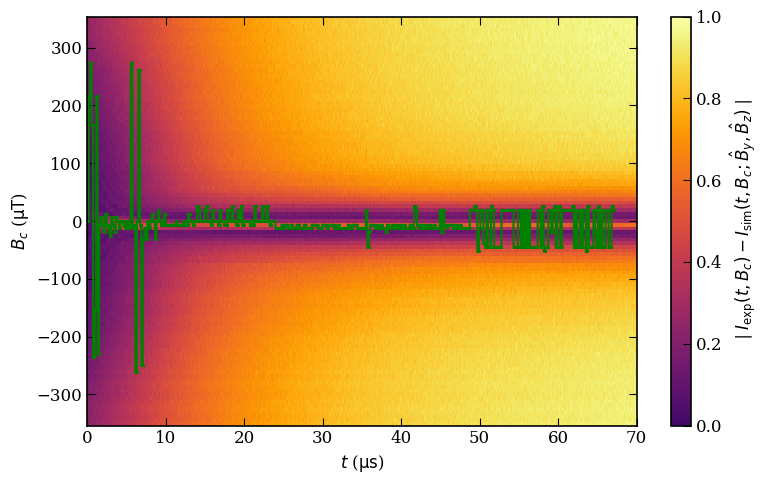

In [49]:
plot_heat_and_surface(
    t_exp.get(),
    f_bias_axis.get() * 100 /0.7,
    exp_matrix.get(),
    # title_prefix="Data",
    trajectory_mode=True,
    traj_bias=bias_applied*100/0.7,
    curr_time=DEFAULT_ESTIMATION_PARAMETERS.curr_time,
    save_path = f'Results\\Dataset_10\\Test_03_08_2026\\Bias_Trajectory_By_{scan_index}.png',
    format = "png"
)

In [50]:
print(r'MAP $B_z$ :',history["map_bz"][-1]*100/0.7, r'$\\$ MAP $B_y$ :',history["map_by"][-1]*100/0.7, r'$\\$ Variance Covariance Matrix : $\\$', history["covariance_matrix"][-1]*(100/0.7)*100/0.7)

MAP $B_z$ : 11.816628535324362 $\\$ MAP $B_y$ : 10.837526446267344 $\\$ Variance Covariance Matrix : $\\$ [[0.02413959 0.00067944]
 [0.00067944 0.04172522]]


Including Bias Marginalisation, 03/08/2026

1. By_0: $\\$
MAP $B_z$ : 11.816628535324362 $\\$ 
MAP $B_y$ : 10.837526446267344 $\\$ 
Variance Covariance Matrix : $\\$ 
[[0.02413959 0.00067944] $\\$
 [0.00067944 0.04172522]]

2. By_1: $\\$
MAP $B_z$ : 5.368586013747328 $\\$ 
MAP $B_y$ : 21.807941162779876 $\\$ 
Variance Covariance Matrix : $\\$ 
[[ 0.12717118 -0.00534797] $\\$
 [-0.00534797  0.38241441]]

3. By_2: $\\$
MAP $B_z$ : 4.569754829900536 $\\$ 
MAP $B_y$ : 30.838337289950204 $\\$ 
Variance Covariance Matrix : $\\$ 
[[ 0.17108793 -0.01386926] $\\$
 [-0.01386926  0.46243268]]

4. By_3: $\\$
MAP $B_z$ : 5.740973482908991 $\\$ 
MAP $B_y$ : 33.65451752548527 $\\$ 
Variance Covariance Matrix : $\\$ 
[[ 0.2013646  -0.01354067] $\\$
 [-0.01354067  0.57769844]]
